In [17]:
# def create_side_by_side_heatmaps(df_64, df_128):
#     fig, axes = plt.subplots(1, 2, figsize=(20, 8))
    
#     datasets = [(df_64, "Hidden Size 64", axes[0]), (df_128, "Hidden Size 128", axes[1])]
    
#     for df, hidden_size, ax in datasets:
#         if df.empty:
#             print(f"No data for {hidden_size}")
#             continue
        
#         # Average across seeds for each (num_params, nonlinear_units) combination
#         df_avg = df.groupby(['Num Individual Params', 'Nonlinear Units'])['Best Avg Test Accuracy'].mean().reset_index()
        
#         # Pivot data for heatmap: rows = num_params, columns = nonlinear_units
#         heatmap_pivot = df_avg.pivot_table(
#             index='Num Individual Params',
#             columns='Nonlinear Units',
#             values='Best Avg Test Accuracy',
#             aggfunc='mean'
#         )
        
#         # Sort indices
#         heatmap_pivot = heatmap_pivot.sort_index(axis=0)
#         heatmap_pivot = heatmap_pivot.sort_index(axis=1)
        
#         # Print missing combinations (NaN cells in the heatmap)
#         missing_combos = []
#         for params in heatmap_pivot.index:
#             for nl in heatmap_pivot.columns:
#                 if pd.isna(heatmap_pivot.loc[params, nl]):
#                     hidden_folder = "hidden_64" if "64" in hidden_size else "hidden_128"
#                     folder = f"seed_0/{hidden_folder}/seed_*/tasks_21_params_{params}_nonlinear_{nl}"
#                     missing_combos.append((params, nl, folder))
        
#         if missing_combos:
#             print(f"\n--- {hidden_size}: {len(missing_combos)} empty heatmap cells ---")
#             for params, nl, folder in missing_combos:
#                 print(f"  params={params}, nonlinear={nl}  ->  {folder}")
#         else:
#             print(f"\n--- {hidden_size}: all heatmap cells have values ---")
        
#         # Find the combination with highest accuracy
#         max_idx = heatmap_pivot.stack().idxmax()
#         max_params, max_nonlinear = max_idx
#         max_accuracy = heatmap_pivot.loc[max_params, max_nonlinear]
        
#         print(f"\n{hidden_size} - Best combination:")
#         print(f"  Nonlinear Units: {max_nonlinear}")
#         print(f"  Num Individual Params: {max_params}")
#         print(f"  Best Avg Test Accuracy: {max_accuracy:.4f}")
        
#         # Create heatmap
#         sns.heatmap(
#             heatmap_pivot,
#             annot=True,
#             fmt='.3f',
#             cmap='Blues',
#             cbar_kws={'label': 'Best Avg Test Accuracy'},
#             ax=ax,
#             vmin=0.0,
#             vmax=1.0,
#             linewidths=0.5,
#             linecolor='gray'
#         )
        
#         ax.set_xlabel('Nonlinear Units', fontsize=12, fontweight='bold')
#         ax.set_ylabel('Number of Individual Parameters', fontsize=12, fontweight='bold')
#         ax.set_title(f'{hidden_size}\nBest: {max_nonlinear} nonlinear, {max_params} params = {max_accuracy:.3f}', 
#                      fontsize=14, fontweight='bold')
    
#     plt.tight_layout()
#     plt.show()

# # Create side-by-side heatmaps
# create_side_by_side_heatmaps(df_64, df_128)

In [1]:
import json
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
import re

# Base path for results
base_path = r"C:\Users\garcias\Documents\Projects\Linear_Nonlinear_Memory\data\nonlinear\fast"

def load_experiment_data(hidden_size_folder):
    """Load data for a specific hidden size (hidden_64 or hidden_128)"""
    all_data = []

    hidden_path = Path(base_path) / hidden_size_folder

    if not hidden_path.exists():
        print(f"Path not found: {hidden_path}")
        return pd.DataFrame()

    for seed_dir in sorted(hidden_path.glob("seed_*")):
        if not seed_dir.is_dir():
            continue

        for task_dir in sorted(seed_dir.glob("tasks_*_params_*")):
            if not task_dir.is_dir():
                continue

            match = re.search(r'params_(\d+)_nonlinear_(\d+)', task_dir.name)
            if not match:
                continue

            num_params = int(match.group(1))
            nonlinear_units = int(match.group(2))
            best_avg_acc = np.nan

            metadata_path = task_dir / "metadata.json"
            if metadata_path.exists():
                try:
                    with open(metadata_path, 'r') as f:
                        metadata = json.load(f)
                    best_avg_acc = metadata.get("best_avg_test_accuracy", np.nan)
                    nonlinear_units = metadata.get("nonlinear_units", nonlinear_units)
                except Exception:
                    pass

            all_data.append({
                'Num Individual Params': num_params,
                'Nonlinear Units': nonlinear_units,
                'Best Avg Test Accuracy': best_avg_acc,
            })

    return pd.DataFrame(all_data)

# Load data for both hidden sizes
print("Loading hidden_64...")
df_64 = load_experiment_data("hidden_64")
print(f"Hidden 64: Loaded {len(df_64)} experiments, {df_64['Best Avg Test Accuracy'].isna().sum()} NaNs")

print("\nLoading hidden_128...")
df_128 = load_experiment_data("hidden_128")
print(f"Hidden 128: Loaded {len(df_128)} experiments, {df_128['Best Avg Test Accuracy'].isna().sum()} NaNs")

Loading hidden_64...
Hidden 64: Loaded 40 experiments, 0 NaNs

Loading hidden_128...
Hidden 128: Loaded 40 experiments, 0 NaNs


In [30]:
combos_64  = set(zip(df_64["Num Individual Params"],  df_64["Nonlinear Units"]))
combos_128 = set(zip(df_128["Num Individual Params"], df_128["Nonlinear Units"]))

only_in_64  = sorted(combos_64  - combos_128)
only_in_128 = sorted(combos_128 - combos_64)

print(f"Folders in hidden_64  but NOT hidden_128 ({len(only_in_64)}):")
for params, nl in only_in_64:
    print(f"  params={params}, nonlinear={nl}")

print(f"\nFolders in hidden_128 but NOT hidden_64  ({len(only_in_128)}):")
for params, nl in only_in_128:
    print(f"  params={params}, nonlinear={nl}")

Folders in hidden_64  but NOT hidden_128 (0):

Folders in hidden_128 but NOT hidden_64  (0):



Hidden Size 64 - Seeds per combination: min=5, max=5

Hidden Size 64 - Best combination (avg across seeds):
  Nonlinear Units: 0
  Num Individual Params: 12
  Best Avg Test Accuracy: 0.8488

Hidden Size 128 - Seeds per combination: min=5, max=5

Hidden Size 128 - Best combination (avg across seeds):
  Nonlinear Units: 0
  Num Individual Params: 4
  Best Avg Test Accuracy: 0.8355


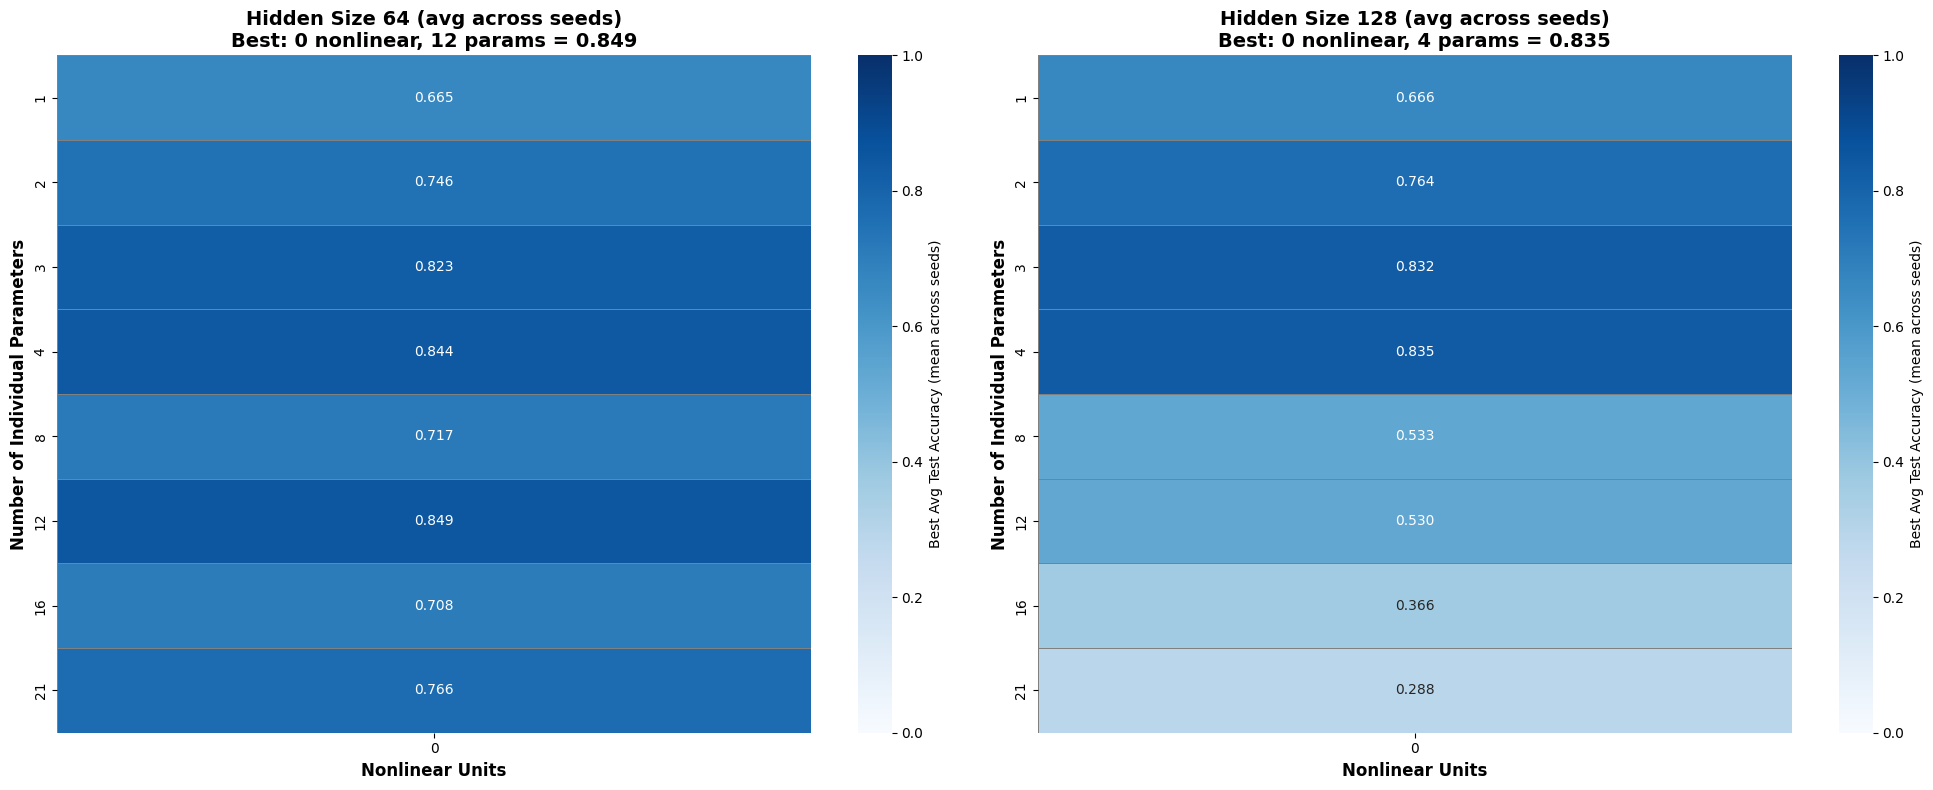

In [2]:
def create_side_by_side_heatmaps(df_64, df_128):
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))
    
    datasets = [(df_64, "Hidden Size 64", axes[0]), (df_128, "Hidden Size 128", axes[1])]
    
    for df, hidden_size, ax in datasets:
        if df.empty:
            print(f"No data for {hidden_size}")
            continue
        
        # Average across seeds
        heatmap_pivot = df.pivot_table(
            index='Num Individual Params',
            columns='Nonlinear Units',
            values='Best Avg Test Accuracy',
            aggfunc='mean'
        )
        heatmap_pivot = heatmap_pivot.sort_index(axis=0).sort_index(axis=1)

        nan_cells = [(p, nl) for p in heatmap_pivot.index for nl in heatmap_pivot.columns
                     if pd.isna(heatmap_pivot.loc[p, nl])]
        if nan_cells:
            hidden_folder = "hidden_64" if "64" in hidden_size else "hidden_128"
            print(f"\n{hidden_size} — missing values ({len(nan_cells)}):")
            for p, nl in nan_cells:
                print(f"  params={p}, nonlinear={nl}")
        
        # Count seeds per combination
        seed_counts = df.groupby(['Num Individual Params', 'Nonlinear Units']).size()
        print(f"\n{hidden_size} - Seeds per combination: min={seed_counts.min()}, max={seed_counts.max()}")
        
        # Find the combination with highest accuracy
        max_idx = heatmap_pivot.stack().idxmax()
        max_params, max_nonlinear = max_idx
        max_accuracy = heatmap_pivot.loc[max_params, max_nonlinear]
        
        print(f"\n{hidden_size} - Best combination (avg across seeds):")
        print(f"  Nonlinear Units: {max_nonlinear}")
        print(f"  Num Individual Params: {max_params}")
        print(f"  Best Avg Test Accuracy: {max_accuracy:.4f}")
        
        sns.heatmap(
            heatmap_pivot,
            annot=True,
            fmt='.3f',
            cmap='Blues',
            cbar_kws={'label': 'Best Avg Test Accuracy (mean across seeds)'},
            ax=ax,
            vmin=0.0,
            vmax=1.0,
            linewidths=0.5,
            linecolor='gray'
        )
        
        ax.set_xlabel('Nonlinear Units', fontsize=12, fontweight='bold')
        ax.set_ylabel('Number of Individual Parameters', fontsize=12, fontweight='bold')
        ax.set_title(f'{hidden_size} (avg across seeds)\nBest: {max_nonlinear} nonlinear, {max_params} params = {max_accuracy:.3f}', 
                     fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.show()

create_side_by_side_heatmaps(df_64, df_128)

In [3]:
# Load data from a specific experiment
exp_path = Path(r"C:\Users\garcias\Documents\Projects\Linear_Nonlinear_Memory\data\nonlinear\fast\hidden_64\seed_1\tasks_21_params_3_nonlinear_0")

# Load metadata
with open(exp_path / "metadata.json", "r") as f:
    metadata = json.load(f)

# Load results
results = np.load(exp_path / "results.npz", allow_pickle=True)

loss_history         = results["loss_history"]
test_loss_history    = results["test_loss_history"]
train_task_accuracies = results["train_task_accuracies"].item()
test_task_accuracies  = results["test_task_accuracies"].item()
train_task_losses    = results["train_task_losses"].item()
test_task_losses     = results["test_task_losses"].item()

task_names = metadata["task_names"]

print("Metadata:")
for k, v in metadata.items():
    if k not in ("task_names", "config"):
        print(f"  {k}: {v}")
print(f"  config: {metadata['config']}")
print("\nResults arrays:")
print(f"  loss_history:          {loss_history.shape}")
print(f"  test_loss_history:     {test_loss_history.shape}")
print(f"  train_task_accuracies: {len(train_task_accuracies)} tasks")
print(f"  test_task_accuracies:  {len(test_task_accuracies)} tasks")

Metadata:
  num_tasks: 21
  num_individual_params: 3
  nonlinear_units: 0
  hidden_size: 64
  seed: 1
  best_test_loss: 0.06458386230994673
  best_avg_test_accuracy: 0.8334580240570592
  timestamp: 2026-03-11T17:48:44.914725
  config: {'obs_size': 7, 'hidden_size': 64, 'nonlinear_units': 0, 'M_reg': 32, 'tau': 0.01, 'num_epochs': 500, 'learning_rate': 0.001, 'individual_learning_rate': 0.001}

Results arrays:
  loss_history:          (8092,)
  test_loss_history:     (476,)
  train_task_accuracies: 21 tasks
  test_task_accuracies:  21 tasks


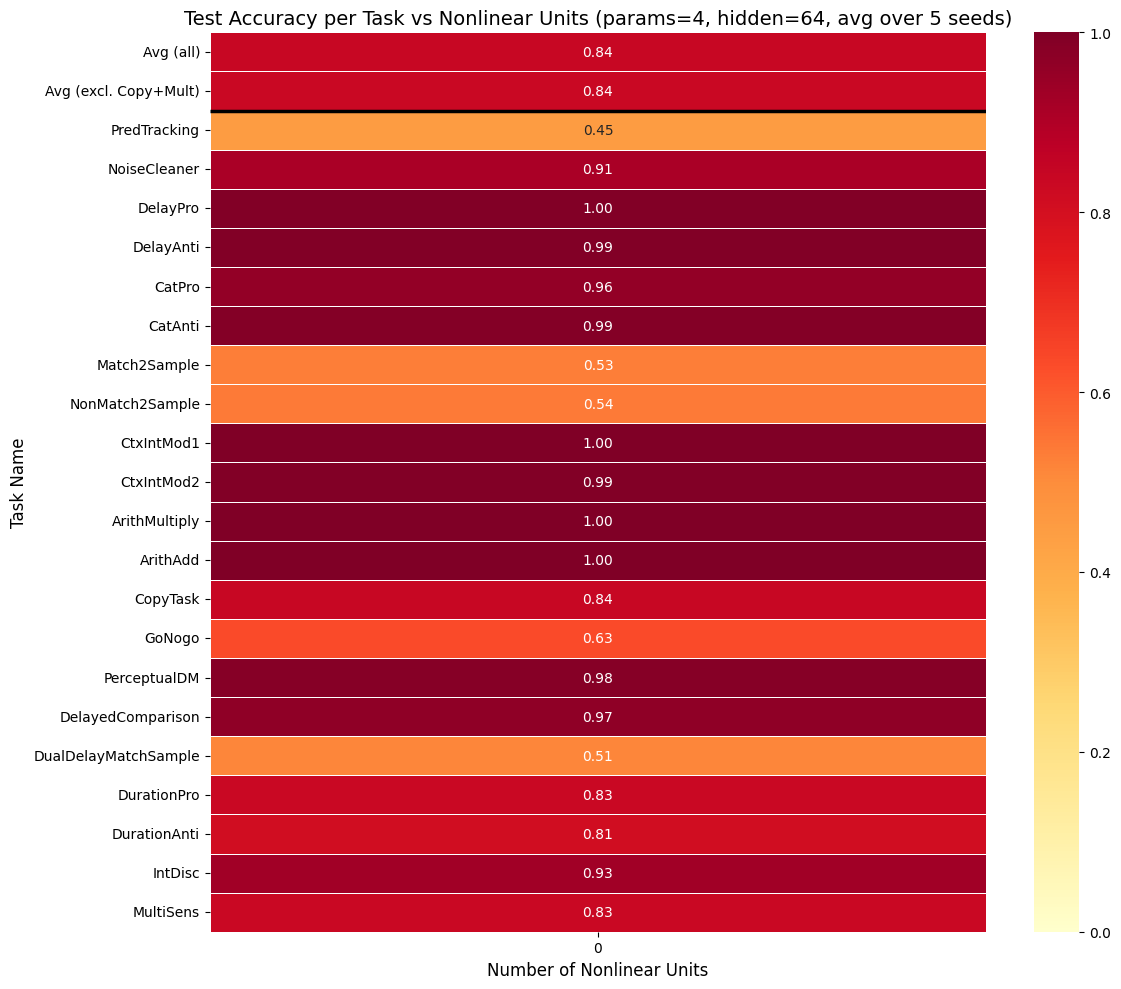

In [4]:
base_path_h64 = Path(r"C:\Users\garcias\Documents\Projects\Linear_Nonlinear_Memory\data\nonlinear\fast\hidden_64")
num_params_fixed = 4

# Collect per-task accuracies across all seeds and nonlinear values
all_accuracies = {}  # {task_name: {nl_val: [acc_seed0, acc_seed1, ...]}}
task_names = None

for seed_dir in sorted(base_path_h64.glob("seed_*")):
    folders = sorted(seed_dir.glob(f"tasks_21_params_{num_params_fixed}_nonlinear_*"))
    for folder in folders:
        nl_val = int(folder.name.split("nonlinear_")[-1])
        data = np.load(folder / "results.npz", allow_pickle=True)
        metadata = json.load(open(folder / "metadata.json"))
        if task_names is None:
            task_names = metadata["task_names"]

        best_idx = np.where(data['test_loss_history'] == metadata["best_test_loss"])[0][0]
        raw = data["test_task_accuracies"].item()

        for k, v in raw.items():
            task_name = task_names[k]
            if task_name not in all_accuracies:
                all_accuracies[task_name] = {}
            if nl_val not in all_accuracies[task_name]:
                all_accuracies[task_name][nl_val] = []
            all_accuracies[task_name][nl_val].append(v[best_idx])

nonlinear_values = sorted({nl for task_accs in all_accuracies.values() for nl in task_accs})
task_names_ordered = list(all_accuracies.keys())

# Build DataFrame with mean across seeds
heatmap_data = pd.DataFrame(index=task_names_ordered, columns=nonlinear_values, dtype=float)
for task in task_names_ordered:
    for nl in nonlinear_values:
        vals = all_accuracies[task].get(nl, [])
        heatmap_data.loc[task, nl] = np.mean(vals) if vals else np.nan

# Average over all tasks
avg_all = heatmap_data.astype(float).mean(axis=0)
excluded = ["CopyTask", "ArithMultiply"]
filtered_tasks = [t for t in task_names_ordered if t not in excluded]
avg_filtered = heatmap_data.loc[filtered_tasks].astype(float).mean(axis=0)

heatmap_data.loc["Avg (all)"] = avg_all
heatmap_data.loc["Avg (excl. Copy+Mult)"] = avg_filtered
heatmap_data = heatmap_data.loc[["Avg (all)", "Avg (excl. Copy+Mult)"] + task_names_ordered]

n_seeds = len(list(base_path_h64.glob("seed_*")))
plt.figure(figsize=(12, 10))
ax = sns.heatmap(heatmap_data.astype(float), annot=True, fmt=".2f", cmap="YlOrRd",
                 vmin=0, vmax=1, linewidths=0.5)
ax.hlines([2], *ax.get_xlim(), colors='black', linewidths=2.5)
plt.xlabel("Number of Nonlinear Units", fontsize=12)
plt.ylabel("Task Name", fontsize=12)
plt.title(f"Test Accuracy per Task vs Nonlinear Units (params={num_params_fixed}, hidden=64, avg over {n_seeds} seeds)", fontsize=14)
plt.tight_layout()
plt.show()

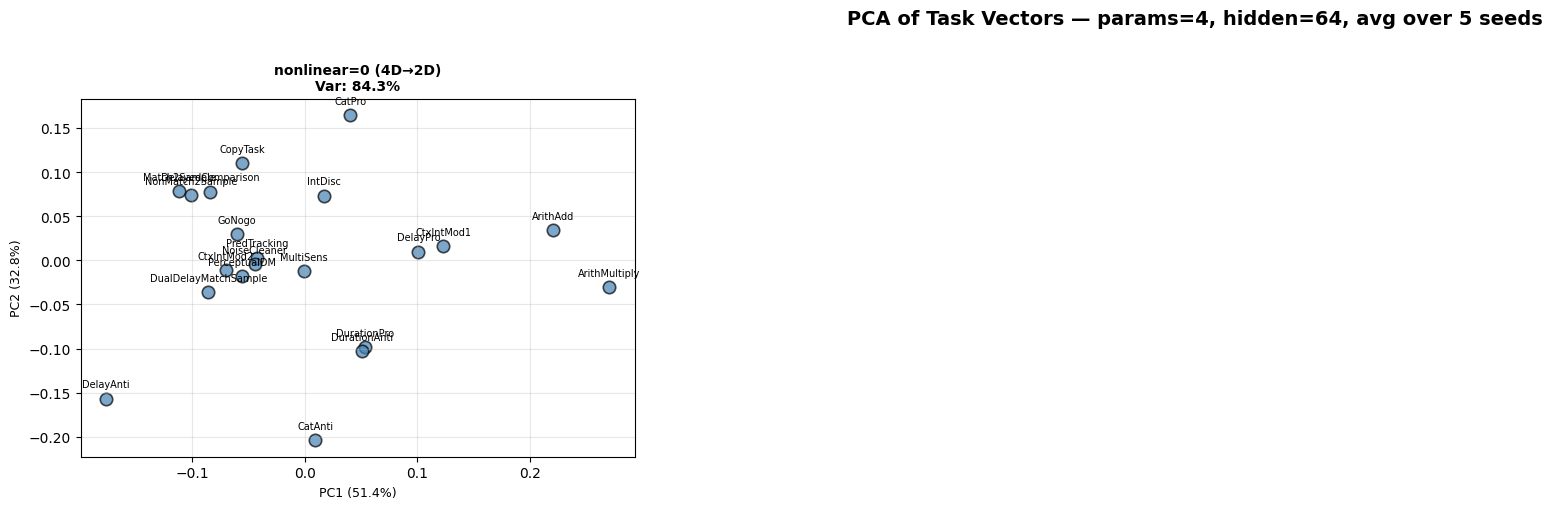

In [5]:
from sklearn.decomposition import PCA
import torch

# --- PCA of Task Vectors for each nonlinear_units value (averaged across seeds) ---
base_path_h64 = Path(r"C:\Users\garcias\Documents\Projects\Linear_Nonlinear_Memory\data\nonlinear\fast\hidden_64")
num_params = 4

# Discover nonlinear values from first seed
first_seed = sorted(base_path_h64.glob("seed_*"))[0]
folders = sorted(first_seed.glob(f"tasks_21_params_{num_params}_nonlinear_*"))
nonlinear_values = sorted([int(f.name.split("nonlinear_")[-1]) for f in folders])

# Average p_vectors across seeds for each nonlinear value
avg_p_vectors = {}
for nl in nonlinear_values:
    seed_pvecs = []
    for seed_dir in sorted(base_path_h64.glob("seed_*")):
        folder = seed_dir / f"tasks_21_params_{num_params}_nonlinear_{nl}"
        if not folder.exists():
            continue
        model = torch.load(folder / "model.pt", map_location="cpu", weights_only=False)
        p_vec = model["p_vector"]
        if isinstance(p_vec, torch.Tensor):
            p_vec = p_vec.cpu().detach().numpy()
        seed_pvecs.append(p_vec)
    avg_p_vectors[nl] = np.mean(seed_pvecs, axis=0)

# Get task names from first available experiment
sample_folder = first_seed / f"tasks_21_params_{num_params}_nonlinear_{nonlinear_values[0]}"
metadata = json.load(open(sample_folder / "metadata.json"))
task_names = metadata["task_names"]

n_seeds = len(list(base_path_h64.glob("seed_*")))
n_plots = len(nonlinear_values)
ncols = 4
nrows = max(1, (n_plots + ncols - 1) // ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows))
if n_plots == 1:
    axes = [axes] if nrows == 1 and ncols == 1 else axes.flatten()
else:
    axes = axes.flatten()

for idx, nl in enumerate(nonlinear_values):
    p_vec = avg_p_vectors[nl]
    pca = PCA(n_components=2)
    p_pca = pca.fit_transform(p_vec)

    ax = axes[idx]
    ax.scatter(p_pca[:, 0], p_pca[:, 1], s=80, alpha=0.7, color='steelblue',
               edgecolors='black', linewidth=1.2)
    for i, task in enumerate(task_names):
        ax.annotate(task, (p_pca[i, 0], p_pca[i, 1]),
                    textcoords="offset points", xytext=(0, 8),
                    ha='center', fontsize=7)
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})', fontsize=9)
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})', fontsize=9)
    ax.set_title(f'nonlinear={nl} ({p_vec.shape[1]}D→2D)\nVar: {sum(pca.explained_variance_ratio_):.1%}',
                 fontsize=10, fontweight='bold')
    ax.grid(alpha=0.3)

for i in range(n_plots, len(axes)):
    axes[i].set_visible(False)

fig.suptitle(f'PCA of Task Vectors — params={num_params}, hidden=64, avg over {n_seeds} seeds',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

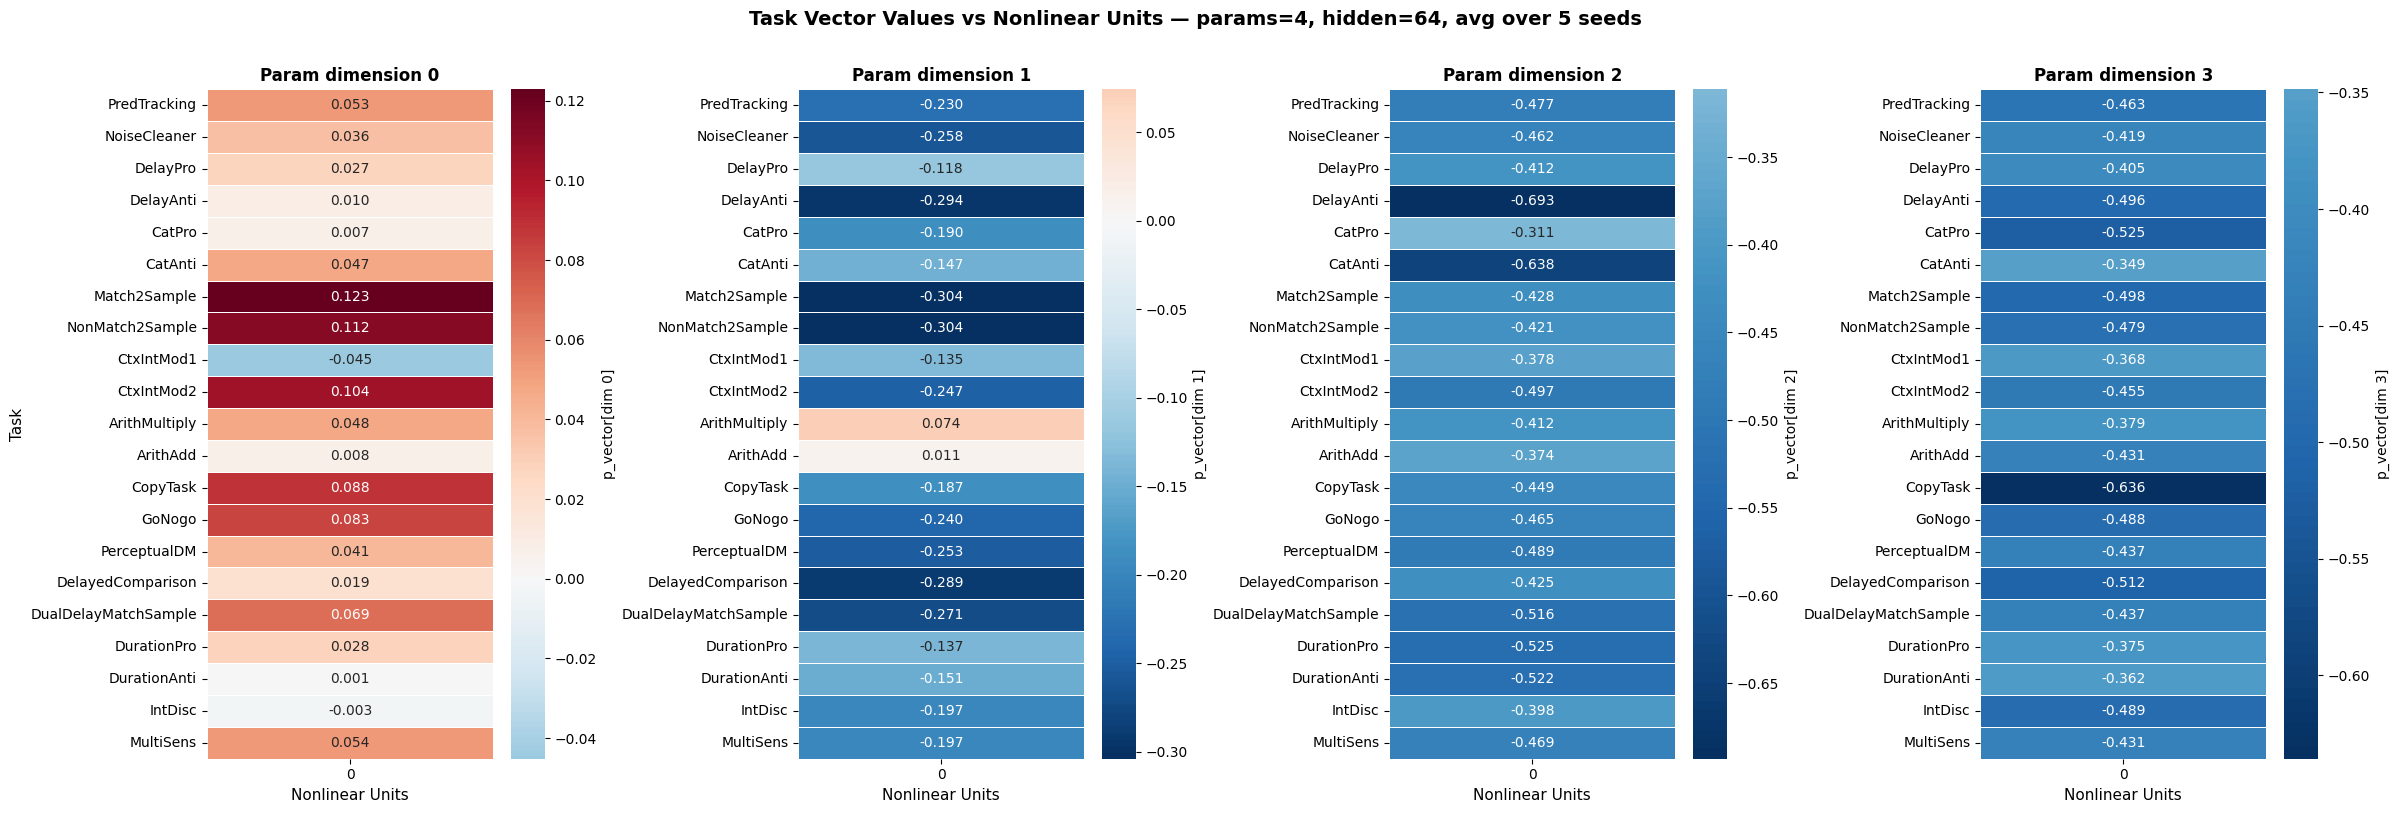

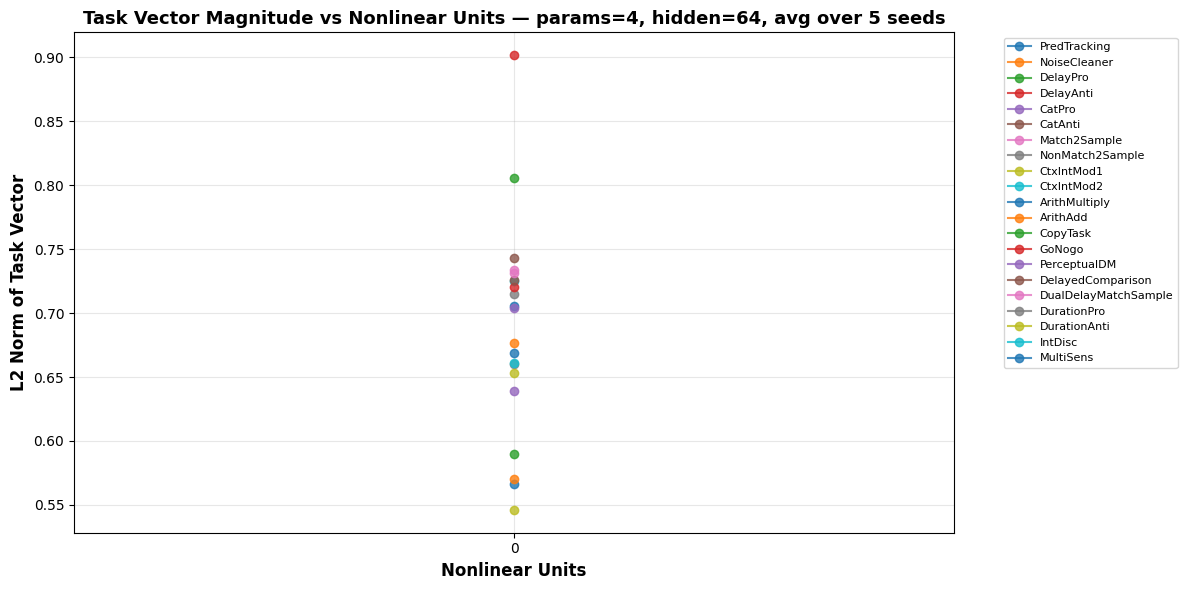

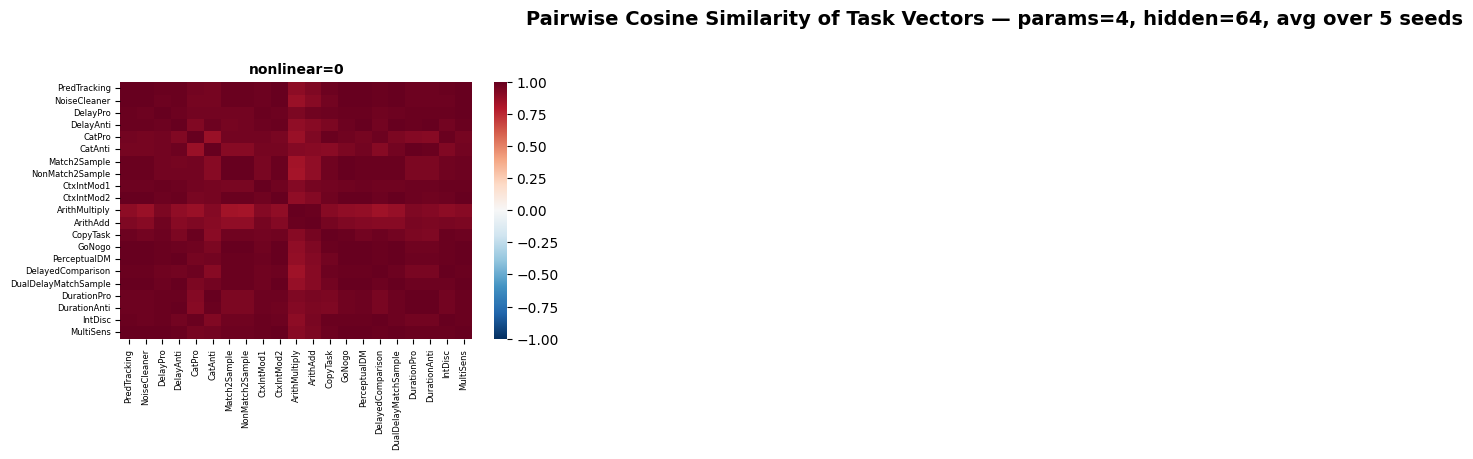

In [6]:
# --- How p_vector values change with increasing nonlinear units (averaged across seeds) ---
base_path_h64 = Path(r"C:\Users\garcias\Documents\Projects\Linear_Nonlinear_Memory\data\nonlinear\fast\hidden_64")
num_params = 4

first_seed = sorted(base_path_h64.glob("seed_*"))[0]
folders = sorted(first_seed.glob(f"tasks_21_params_{num_params}_nonlinear_*"))
nonlinear_values = sorted([int(f.name.split("nonlinear_")[-1]) for f in folders])

# Collect and average p_vectors across seeds
p_vectors = {}
task_names = None
for nl in nonlinear_values:
    seed_pvecs = []
    for seed_dir in sorted(base_path_h64.glob("seed_*")):
        folder = seed_dir / f"tasks_21_params_{num_params}_nonlinear_{nl}"
        if not folder.exists():
            continue
        model = torch.load(folder / "model.pt", map_location="cpu", weights_only=False)
        metadata = json.load(open(folder / "metadata.json"))
        if task_names is None:
            task_names = metadata["task_names"]
        p_vec = model["p_vector"]
        if isinstance(p_vec, torch.Tensor):
            p_vec = p_vec.cpu().detach().numpy()
        seed_pvecs.append(p_vec)
    p_vectors[nl] = np.mean(seed_pvecs, axis=0)

n_seeds = len(list(base_path_h64.glob("seed_*")))

# --- Plot 1: Heatmap of p_vector per task for each nonlinear value (one subplot per param dim) ---
n_params_dim = p_vectors[nonlinear_values[0]].shape[1]
fig, axes = plt.subplots(1, n_params_dim, figsize=(6 * n_params_dim, 8))
if n_params_dim == 1:
    axes = [axes]

for d in range(n_params_dim):
    mat = np.zeros((len(task_names), len(nonlinear_values)))
    for j, nl in enumerate(nonlinear_values):
        mat[:, j] = p_vectors[nl][:, d]

    df_heat = pd.DataFrame(mat, index=task_names, columns=nonlinear_values)
    sns.heatmap(df_heat, annot=True, fmt=".3f", cmap="RdBu_r", center=0,
                linewidths=0.5, ax=axes[d], cbar_kws={'label': f'p_vector[dim {d}]'})
    axes[d].set_xlabel("Nonlinear Units", fontsize=11)
    axes[d].set_ylabel("Task" if d == 0 else "", fontsize=11)
    axes[d].set_title(f"Param dimension {d}", fontsize=12, fontweight='bold')

fig.suptitle(f"Task Vector Values vs Nonlinear Units — params={num_params}, hidden=64, avg over {n_seeds} seeds",
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# --- Plot 2: Per-task L2 norm of p_vector across nonlinear units ---
fig, ax = plt.subplots(figsize=(12, 6))
for i, task in enumerate(task_names):
    norms = [np.linalg.norm(p_vectors[nl][i]) for nl in nonlinear_values]
    ax.plot(nonlinear_values, norms, marker='o', label=task, alpha=0.8)

ax.set_xlabel("Nonlinear Units", fontsize=12, fontweight='bold')
ax.set_ylabel("L2 Norm of Task Vector", fontsize=12, fontweight='bold')
ax.set_title(f"Task Vector Magnitude vs Nonlinear Units — params={num_params}, hidden=64, avg over {n_seeds} seeds",
             fontsize=13, fontweight='bold')
ax.set_xticks(nonlinear_values)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# --- Plot 3: Pairwise cosine similarity between tasks, for each nonlinear value ---
from sklearn.metrics.pairwise import cosine_similarity

ncols = 4
nrows = max(1, (len(nonlinear_values) + ncols - 1) // ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4.5 * nrows))
axes = np.atleast_1d(axes).flatten()

for idx, nl in enumerate(nonlinear_values):
    cos_sim = cosine_similarity(p_vectors[nl])
    df_cos = pd.DataFrame(cos_sim, index=task_names, columns=task_names)
    sns.heatmap(df_cos, cmap="RdBu_r", center=0, vmin=-1, vmax=1,
                ax=axes[idx], cbar=idx == len(nonlinear_values) - 1,
                xticklabels=True, yticklabels=True)
    axes[idx].set_title(f"nonlinear={nl}", fontsize=10, fontweight='bold')
    axes[idx].tick_params(labelsize=6)

for i in range(len(nonlinear_values), len(axes)):
    axes[i].set_visible(False)

fig.suptitle(f"Pairwise Cosine Similarity of Task Vectors — params={num_params}, hidden=64, avg over {n_seeds} seeds",
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

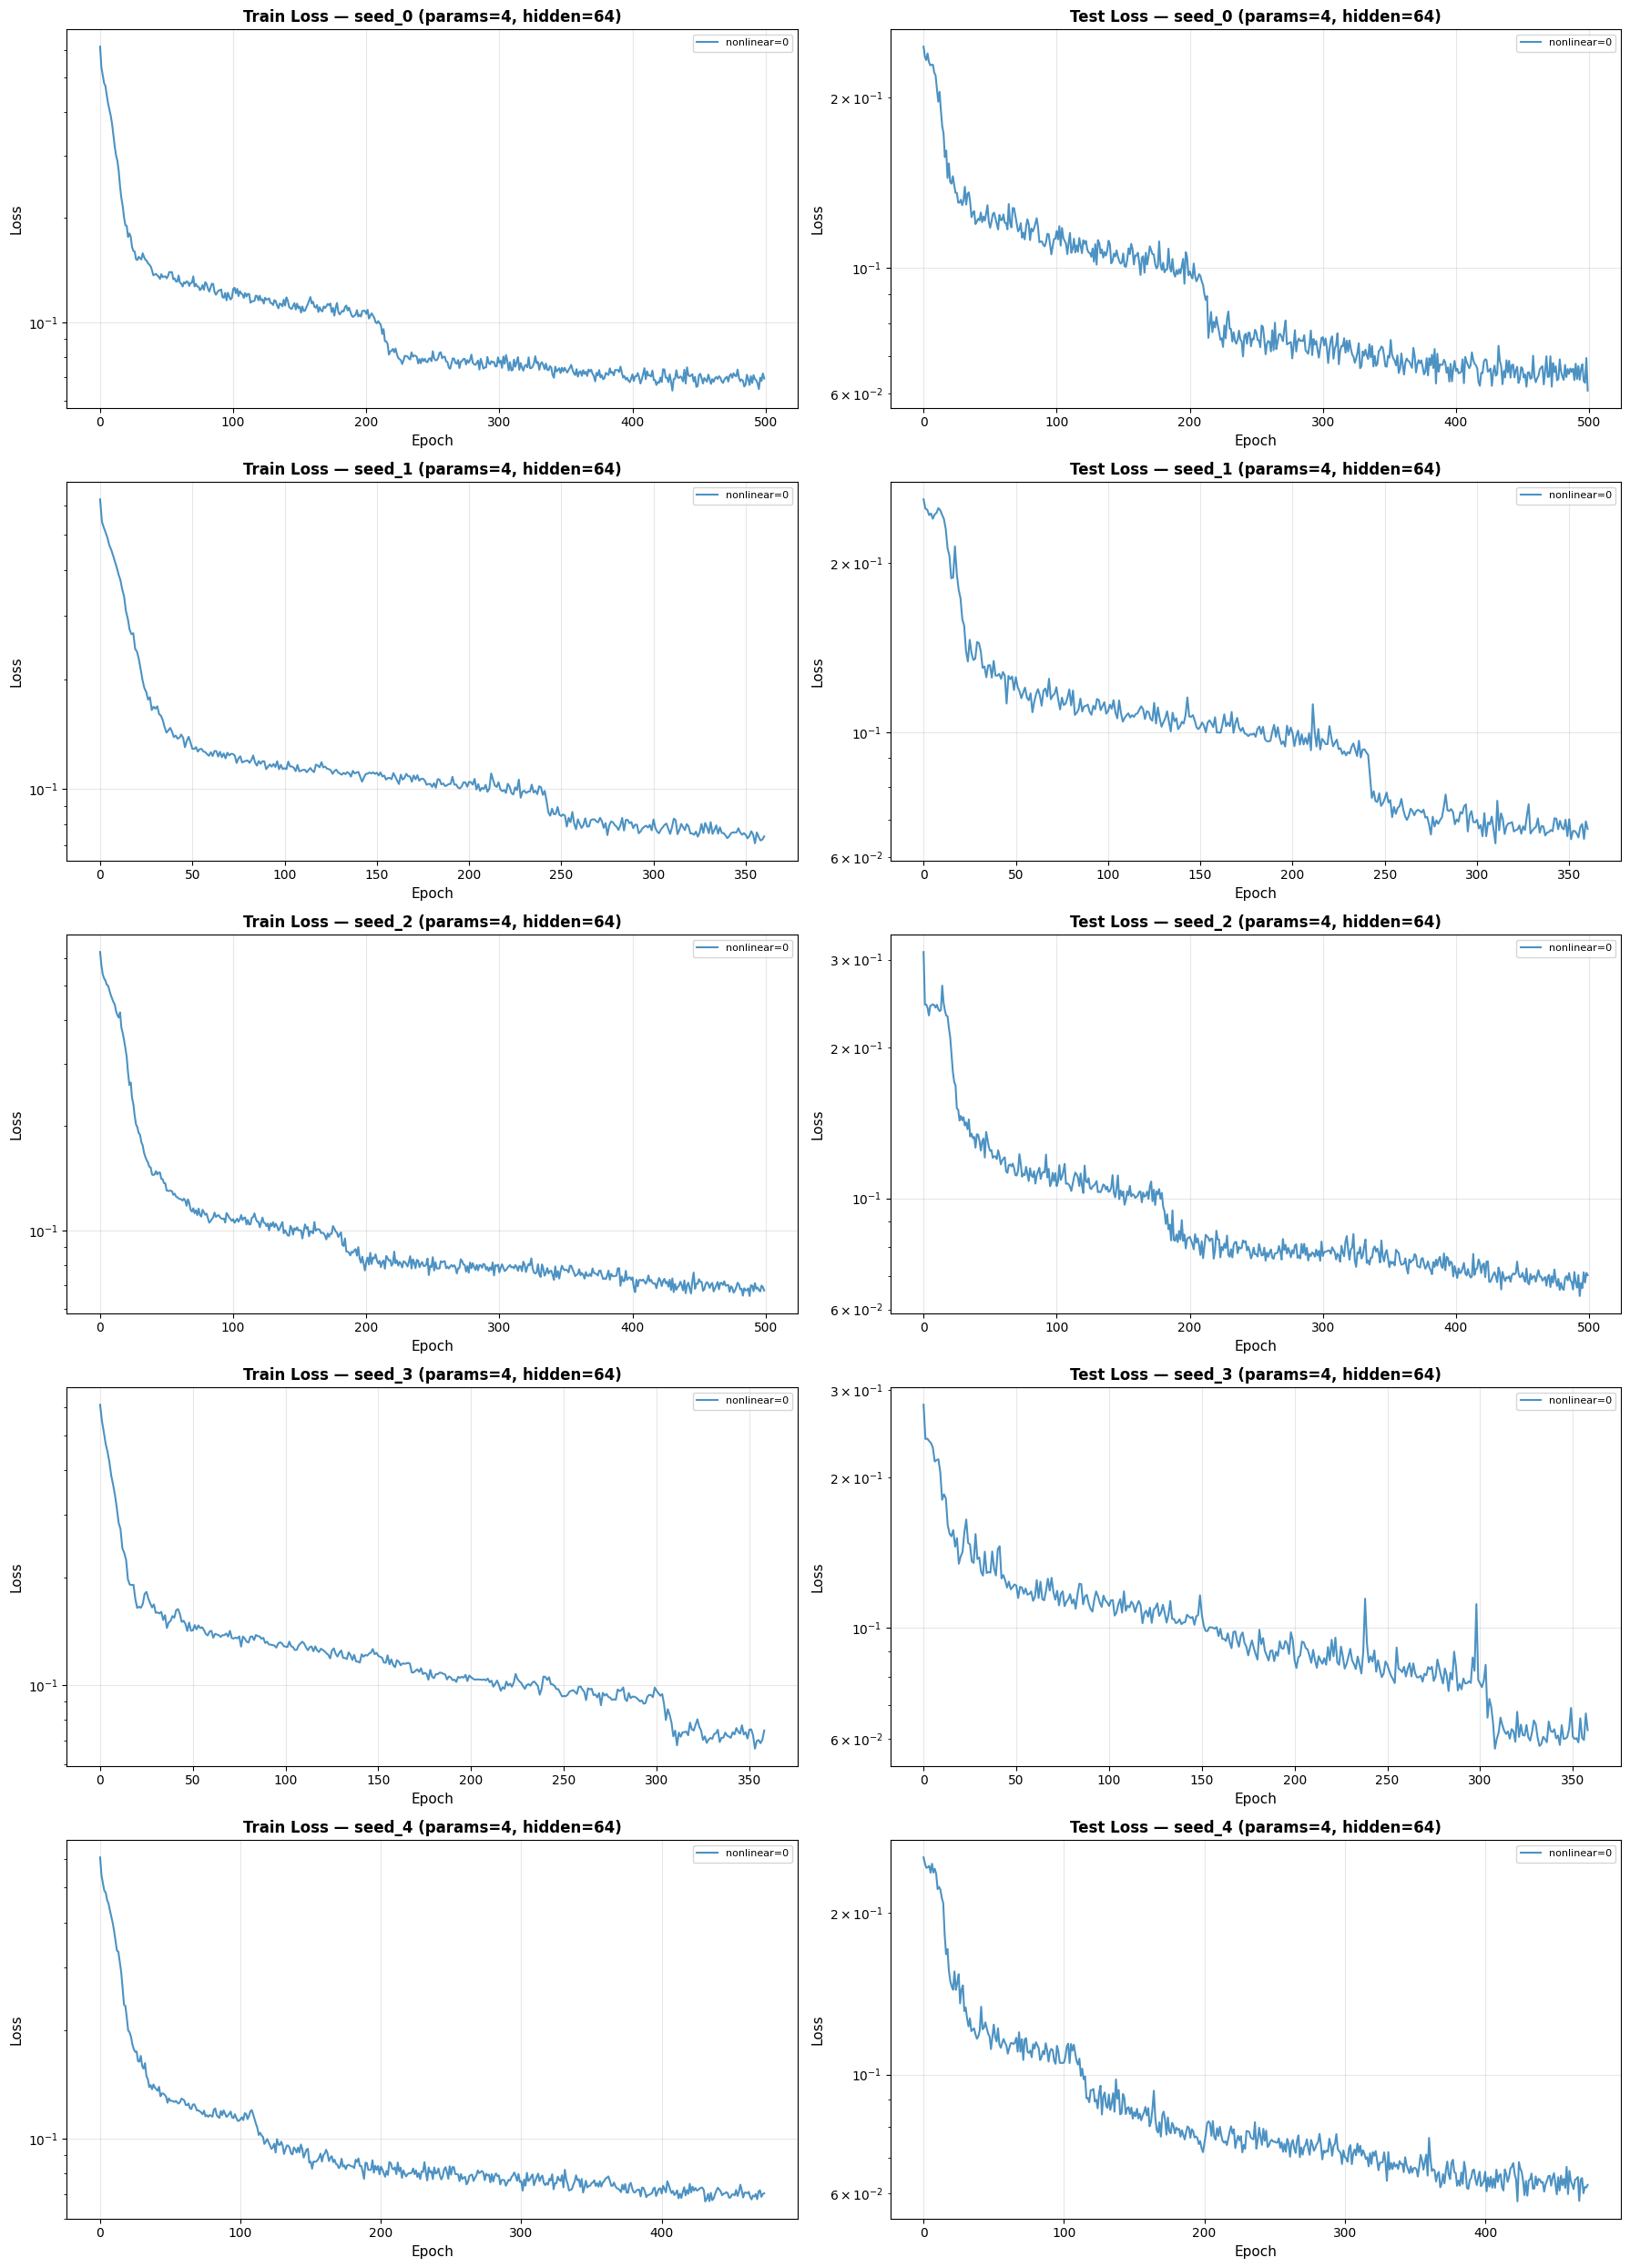

In [11]:
# --- Training loss curves for params=4, hidden=64, one subplot per seed ---
base_path_h64 = Path(r"C:\Users\garcias\Documents\Projects\Linear_Nonlinear_Memory\data\nonlinear\fast\hidden_64")
num_params = 4

seed_dirs = sorted(base_path_h64.glob("seed_*"))
first_seed = seed_dirs[0]
folders = sorted(first_seed.glob(f"tasks_21_params_{num_params}_nonlinear_*"))
nonlinear_values = sorted([int(f.name.split("nonlinear_")[-1]) for f in folders])

n_seeds = len(seed_dirs)
fig, axes = plt.subplots(n_seeds, 2, figsize=(18, 5 * n_seeds), squeeze=False)

for row, seed_dir in enumerate(seed_dirs):
    seed_name = seed_dir.name
    for nl in nonlinear_values:
        folder = seed_dir / f"tasks_21_params_{num_params}_nonlinear_{nl}"
        if not folder.exists():
            continue
        results = np.load(folder / "results.npz", allow_pickle=True)
        train_loss = results["loss_history"]
        test_loss = results["test_loss_history"]

        # Take last train loss value per epoch
        n_epochs = len(test_loss)
        steps_per_epoch = len(train_loss) / n_epochs
        train_per_epoch = [train_loss[int((e + 1) * steps_per_epoch) - 1] for e in range(n_epochs)]

        label = f"nonlinear={nl}"
        axes[row, 0].plot(train_per_epoch, label=label, alpha=0.8)
        axes[row, 1].plot(test_loss, label=label, alpha=0.8)

    for col, title in enumerate(["Train Loss", "Test Loss"]):
        axes[row, col].set_xlabel("Epoch", fontsize=11)
        axes[row, col].set_ylabel("Loss", fontsize=11)
        axes[row, col].set_title(f"{title} — {seed_name} (params={num_params}, hidden=64)", fontsize=12, fontweight='bold')
        axes[row, col].legend(fontsize=8)
        axes[row, col].grid(alpha=0.3)
        axes[row, col].set_yscale('log')

plt.tight_layout()
plt.show()

In [8]:
%matplotlib tk


# --- Interactive per-task loss curves with multi-select hidden sizes, seeds, and params ---

import json


import numpy as np

import matplotlib.pyplot as plt

from matplotlib.colors import to_rgb

from matplotlib.widgets import RadioButtons, CheckButtons, Button

from pathlib import Path


base_path = Path(r"C:\Users\garcias\Documents\Projects\Linear_Nonlinear_Memory\data\nonlinear\fast")


# Discover available options

hidden_dirs = sorted([d.name for d in base_path.glob("hidden_*") if d.is_dir()])


all_seed_dirs = sorted({

    d.name

    for hidden in hidden_dirs

    for d in (base_path / hidden).glob("seed_*")

    if d.is_dir()

})


all_params = sorted({

    int(m.group(1))

    for hidden in hidden_dirs

    for seed in all_seed_dirs

    for d in (base_path / hidden / seed).glob("tasks_*_params_*_nonlinear_*")

    if d.is_dir()

    for m in [re.search(r'params_(\d+)_nonlinear_(\d+)', d.name)]

    if m

})


# Load task names from first available experiment

first_exp = None

for hidden in hidden_dirs:

    for seed in all_seed_dirs:

        exps = sorted((base_path / hidden / seed).glob("tasks_*"))

        if exps:

            first_exp = exps[0]

            break

    if first_exp is not None:

        break


with open(first_exp / "metadata.json", "r") as f:

    task_names = json.load(f)["task_names"]


# State

default_param = 4 if 4 in all_params else all_params[0]

state = {

    "selected_hidden": set(hidden_dirs),

    "selected_seeds": set(all_seed_dirs),

    "selected_params": {default_param},

    "loss_type": "both",

    "selected_tasks": set(range(len(task_names))),

    "suspend_callbacks": False,

}


# Layout

fig = plt.figure(figsize=(22, 11))

ax_hidden = fig.add_axes([0.01, 0.77, 0.10, 0.20])

ax_seed = fig.add_axes([0.01, 0.46, 0.10, 0.28])

ax_params = fig.add_axes([0.01, 0.24, 0.10, 0.18])

ax_loss = fig.add_axes([0.01, 0.10, 0.08, 0.10])

ax_clear = fig.add_axes([0.01, 0.02, 0.10, 0.05])

ax_tasks = fig.add_axes([0.86, 0.02, 0.13, 0.96])

ax_main = fig.add_axes([0.14, 0.08, 0.68, 0.85])


check_hidden = CheckButtons(ax_hidden, hidden_dirs, [h in state["selected_hidden"] for h in hidden_dirs])

check_seed = CheckButtons(ax_seed, all_seed_dirs, [s in state["selected_seeds"] for s in all_seed_dirs])

check_params = CheckButtons(ax_params, [str(p) for p in all_params], [p in state["selected_params"] for p in all_params])

radio_loss = RadioButtons(ax_loss, ["both", "test", "train"], active=0)

button_clear = Button(ax_clear, "Unselect everything")

check_tasks = CheckButtons(ax_tasks, task_names, [True] * len(task_names))


ax_hidden.set_title("Hidden", fontsize=9, fontweight="bold")

ax_seed.set_title("Seeds", fontsize=9, fontweight="bold")

ax_params.set_title("Params", fontsize=9, fontweight="bold")

ax_loss.set_title("Loss", fontsize=9, fontweight="bold")

ax_tasks.set_title("Tasks", fontsize=9, fontweight="bold")


task_palette = plt.cm.tab20(np.linspace(0, 1, len(task_names)))

seed_palette = plt.cm.Set2(np.linspace(0, 1, max(len(all_seed_dirs), 3)))

seed_color_map = {seed: seed_palette[index % len(seed_palette)] for index, seed in enumerate(all_seed_dirs)}


def get_train_per_epoch(train_arr, n_epochs):

    if n_epochs == 0:

        return []

    steps_per_epoch = len(train_arr) / n_epochs

    return [train_arr[int((e + 1) * steps_per_epoch) - 1] for e in range(n_epochs)]


def blend_colors(color_a, color_b, weight=0.5):

    rgb_a = np.array(to_rgb(color_a))

    rgb_b = np.array(to_rgb(color_b))

    mixed = (1 - weight) * rgb_a + weight * rgb_b

    return np.clip(mixed, 0.0, 1.0)


def uncheck_selected(widget, selected_labels):

    for index, label in enumerate(widget.labels):

        if label.get_text() in selected_labels and widget.get_status()[index]:

            widget.set_active(index)


def uncheck_selected_tasks(widget, selected_indices):

    for index in sorted(selected_indices):

        if widget.get_status()[index]:

            widget.set_active(index)


def update(val=None):

    ax_main.clear()


    selected_hidden = sorted(state["selected_hidden"])

    selected_seeds = sorted(state["selected_seeds"])

    selected_params = sorted(state["selected_params"])

    loss_type = state["loss_type"]


    if not selected_hidden:

        ax_main.text(0.5, 0.5, "No hidden sizes selected", ha="center", va="center", fontsize=14)

        fig.canvas.draw_idle()

        return


    if not selected_seeds:

        ax_main.text(0.5, 0.5, "No seeds selected", ha="center", va="center", fontsize=14)

        fig.canvas.draw_idle()

        return


    if not selected_params:

        ax_main.text(0.5, 0.5, "No params selected", ha="center", va="center", fontsize=14)

        fig.canvas.draw_idle()

        return


    linestyles = ['-', '--', ':', '-.'] * 20


    plotted_any = False

    legend_entries = 0

    style_index = 0


    for hidden in selected_hidden:

        for params in selected_params:

            for seed in selected_seeds:

                seed_dir = base_path / hidden / seed

                folders = sorted(seed_dir.glob(f"tasks_*_params_{params}_nonlinear_*"))


                if not folders:

                    continue


                nonlinear_values = sorted([

                    int(f.name.split("nonlinear_")[-1])

                    for f in folders

                    if f.is_dir()

                ])


                for nl in nonlinear_values:

                    folder = seed_dir / f"tasks_21_params_{params}_nonlinear_{nl}"

                    if not folder.exists():

                        matches = list(seed_dir.glob(f"tasks_*_params_{params}_nonlinear_{nl}"))

                        if not matches:

                            continue

                        folder = matches[0]


                    results_path = folder / "results.npz"

                    if not results_path.exists():

                        continue


                    results = np.load(results_path, allow_pickle=True)

                    test_task_losses = results["test_task_losses"].item()

                    train_task_losses = results["train_task_losses"].item()


                    n_epochs = len(list(test_task_losses.values())[0]) if test_task_losses else 0

                    linestyle = linestyles[style_index % len(linestyles)]

                    style_index += 1


                    for k in test_task_losses:

                        if k not in state["selected_tasks"]:

                            continue


                        plotted_any = True

                        task_label = task_names[k]

                        base_task_color = task_palette[k]

                        seed_color = seed_color_map[seed]

                        line_color = blend_colors(base_task_color, seed_color, weight=0.45)


                        if loss_type in ("train", "both"):

                            train_arr = train_task_losses[k]

                            train_per_epoch = get_train_per_epoch(train_arr, n_epochs)

                            ax_main.plot(

                                train_per_epoch,

                                color=line_color,

                                alpha=0.20,

                                linewidth=0.8,

                                linestyle=linestyle

                            )


                        if loss_type in ("test", "both"):

                            label = f"{task_label} | {hidden} | {seed} | p={params} | nl={nl}"

                            ax_main.plot(

                                test_task_losses[k],

                                color=line_color,

                                alpha=0.85,

                                linewidth=1.5,

                                linestyle=linestyle,

                                label=label

                            )

                            legend_entries += 1


    if not plotted_any:

        ax_main.text(0.5, 0.5, "No matching data found", ha="center", va="center", fontsize=14)

        fig.canvas.draw_idle()

        return


    ax_main.set_xlabel("Epoch", fontsize=11)

    ax_main.set_ylabel("Loss", fontsize=11)

    ax_main.set_yscale("log")

    ax_main.grid(alpha=0.3)


    label_str = {

        "test": "Test",

        "train": "Train",

        "both": "Train (thin) + Test (thick)"

    }[loss_type]


    hidden_str = ", ".join(selected_hidden)

    seeds_str = ", ".join(selected_seeds)

    params_str = ", ".join(map(str, selected_params))

    ax_main.set_title(

        f"Per-Task {label_str} Loss\nHidden: {hidden_str} | Seeds: {seeds_str} | Params: {params_str}",

        fontsize=13,

        fontweight="bold"

    )


    if len(state["selected_tasks"]) <= 5 and legend_entries <= 30 and loss_type in ("test", "both"):

        ax_main.legend(fontsize=7, loc="upper right", ncol=2)


    fig.canvas.draw_idle()


def on_hidden(label):

    if state["suspend_callbacks"]:

        return

    if label in state["selected_hidden"]:

        state["selected_hidden"].remove(label)

    else:

        state["selected_hidden"].add(label)

    update()


def on_seed(label):

    if state["suspend_callbacks"]:

        return

    if label in state["selected_seeds"]:

        state["selected_seeds"].remove(label)

    else:

        state["selected_seeds"].add(label)

    update()


def on_params(label):

    if state["suspend_callbacks"]:

        return

    value = int(label)

    if value in state["selected_params"]:

        state["selected_params"].remove(value)

    else:

        state["selected_params"].add(value)

    update()


def on_loss(label):

    if state["suspend_callbacks"]:

        return

    state["loss_type"] = label

    update()


def on_task(label):

    if state["suspend_callbacks"]:

        return

    idx = task_names.index(label)

    if idx in state["selected_tasks"]:

        state["selected_tasks"].remove(idx)

    else:

        state["selected_tasks"].add(idx)

    update()


def on_clear(event):

    state["suspend_callbacks"] = True

    uncheck_selected(check_hidden, set(state["selected_hidden"]))

    uncheck_selected(check_seed, set(state["selected_seeds"]))

    uncheck_selected(check_params, {str(p) for p in state["selected_params"]})

    uncheck_selected_tasks(check_tasks, set(state["selected_tasks"]))

    state["suspend_callbacks"] = False

    state["selected_hidden"].clear()

    state["selected_seeds"].clear()

    state["selected_params"].clear()

    state["selected_tasks"].clear()

    update()


check_hidden.on_clicked(on_hidden)

check_seed.on_clicked(on_seed)

check_params.on_clicked(on_params)

radio_loss.on_clicked(on_loss)

button_clear.on_clicked(on_clear)

check_tasks.on_clicked(on_task)


update()

plt.show()
